In [63]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np


import seaborn as sns
sns.set_theme(context="talk", palette="crest")



In [65]:
figurepath = "/home/esell/Documentos/Ciencia/UNICAMP/[Proj]onChipOPO/Calculations_new/r-2r-r-molecule/figures/"
datapath   = "/home/esell/Documentos/Ciencia/UNICAMP/[Proj]onChipOPO/Calculations_new/r-2r-r-molecule/data/"

### Overlap

In [66]:
df_s  = pd.read_csv(datapath + "DOPO overlap symmetric.csv")
df_as = pd.read_csv(datapath + "DOPO overlap asymmetric.csv")

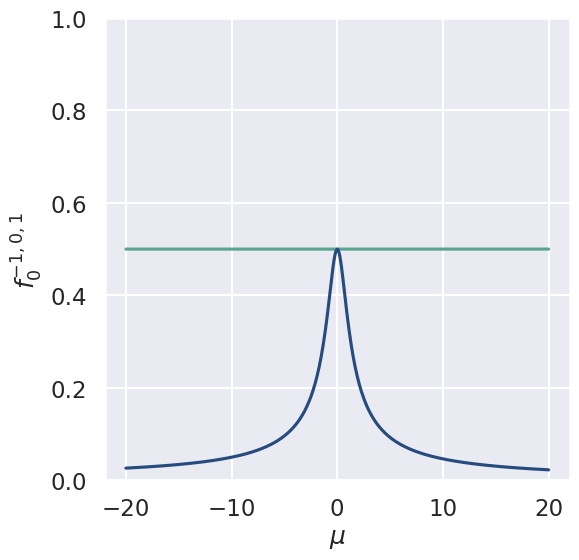

In [71]:
f, ax = plt.subplots(figsize=(6, 6))

ax.plot(df_s.mu, df_s.f_DOPO, color = "C1")
ax.plot(df_as.mu, df_as.f_DOPO, color = "C5")

ax.set_ylim(0, 1)

ax.set_xlabel("$\\mu$")
ax.set_ylabel("$f_0^{-1, 0, 1}$")

f.savefig(figurepath + "DOPO overlap.svg")

### gain

In [72]:
dfg_s  = pd.read_csv(datapath + "gain.csv")
dfg_s["g"] = dfg_s["g"].str.replace(" + 0.i", "").astype("float")

dfg_as = pd.read_csv(datapath + "gain_as.csv")
dfg_as["g"] = dfg_as["g"].str.replace(" + 0.i", "").astype("float")


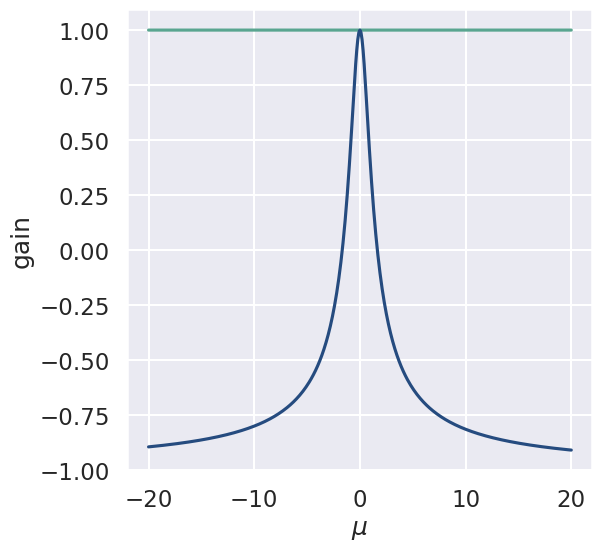

In [73]:
f, ax = plt.subplots(figsize=(6, 6))

ax.plot(dfg_s.mu, dfg_s.g, color = "C1")
ax.plot(dfg_as.mu, dfg_as.g, color = "C5")

# ax.set_ylim(0, 1)

ax.set_xlabel("$\\mu$")
ax.set_ylabel("gain")

f.savefig(figurepath + "DOPO overlap.svg")

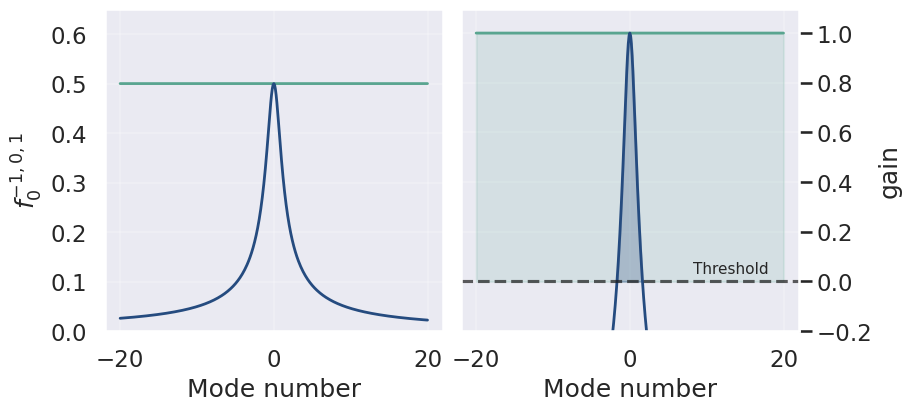

In [83]:
f, ax = plt.subplots(1, 2, sharex=True, figsize=(9,4), constrained_layout=True)

# c_sym  = "#60b1adff"
# c_asym = "#1a5fb4ff"

c_sym  = "C1"   # teal mais claro (mais brilho)
c_asym = "C5"   # azul mais profundo (mais escuro)

ax[0].plot(df_s.mu, df_s.f_DOPO, color=c_sym, lw=2)
ax[0].plot(df_as.mu, df_as.f_DOPO, color=c_asym, lw=2)

ax[0].set_ylim(0, .65)

ax[0].set_xlabel("Mode number")
ax[0].set_ylabel("$f_0^{-1, 0, 1}$")



ax[1].plot(dfg_s.mu, dfg_s.g,  color=c_sym, lw=2)
ax[1].plot(dfg_as.mu, dfg_as.g,  color=c_asym, lw=2)

ax[1].set_ylim(ymin=-0.2)
lims = ax[1].get_xlim()

ax[1].hlines(0, *lims, "k", ls="--", alpha=0.7)
ax[1].text(18, 0.05, "Threshold", ha="right", va="center", fontsize=11)

ax[1].set_xlim(*lims)

ax[1].set_xlabel("Mode number")
ax[1].set_ylabel("gain")

ax[1].fill_between(dfg_s.mu, dfg_s.g, 0, where=(dfg_s.g > 0),
                   color=c_sym, alpha=0.15)

ax[1].fill_between(dfg_as.mu, dfg_as.g, 0, where=(dfg_as.g > 0),
                   color=c_asym, alpha=0.25)


ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

# --- estilo ---
for a in ax:
    a.grid(True, alpha=0.2)

# f.tight_layout()
f.savefig(figurepath + "DOPO overlap and gain.svg")